# TP1 – Predicción del diagnóstico de cáncer de tiroides
**Curso:** CC209 – Data Mining Tools · **Docente:** Carlos Fernando Montoya Cubas · **NRC:** 17496 · **Grupo 2**

**Integrantes:** Gomez Rubina, Luis David (U20221C621) · Miranda Cárdenas, Sofía (U20191C439)

Este notebook es el primer corte formal del proyecto. Cubre: definición del problema, dataset,
EDA, calidad y preparación, separación de datos, pipeline reproducible, baseline, modelos
preliminares, evaluación y plan hacia el TF1.

> **Convención de lectura.** En cada sección distinguimos **📊 Lo que muestran los datos**
> (hecho verificable en la salida) de **💭 Interpretación del grupo** (hipótesis o lectura nuestra).

## 1. Definición del problema (resumen)
| Elemento | Definición |
|---|---|
| Contexto | El cáncer de tiroides es una de las neoplasias endocrinas más frecuentes; la evaluación clínica integra muchos factores heterogéneos. |
| Necesidad | Priorizar qué pacientes requieren estudios confirmatorios (p. ej., biopsia PAAF) a partir de datos clínicos y antecedentes. |
| Unidad de análisis | Un paciente (`Patient_ID`). |
| **Pregunta principal** | ¿Con qué capacidad se puede distinguir un diagnóstico **maligno** de uno **benigno** a partir de datos demográficos, antecedentes, perfil hormonal (TSH, T3, T4) y tamaño del nódulo, y qué factores aportan esa capacidad? |
| Tipo de problema | Clasificación binaria supervisada (`Diagnosis`: Benign / Malignant), con clases desbalanceadas. |
| Utilidad | Herramienta de **priorización (triaje)**, no de diagnóstico: ordenar pacientes por probabilidad de malignidad. |
| Criterios de utilidad | (1) Superar claramente al baseline en ROC-AUC y PR-AUC; (2) mejorar el recall de *Malignant* frente a una regla simple del dominio sin disparar los falsos positivos; (3) que los factores relevantes sean clínicamente coherentes. |

**Decisión:** el proyecto trabaja con una sola variable objetivo, `Diagnosis`. `Thyroid_Cancer_Risk` **no se usa como predictor**
(es un puntaje precalculado de origen desconocido: ver §3.6) y se reserva como **regla de referencia** del dominio.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import config as C
from src.data import load_raw, quality_report, clean, get_xy, split
from src.features import build_preprocessor
from src.models import make_pipelines
from src.evaluate import evaluate, results_table

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
C.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Estilo de gráficos (paleta validada para daltonismo: azul = Benign, naranja = Malignant)
BENIGN, MALIG, GRAY = "#2a78d6", "#eb6834", "#8a8984"
PAL = {"Benign": BENIGN, "Malignant": MALIG}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#b5b4ae", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.titleweight": "bold", "axes.titlesize": 11, "font.size": 10,
})
def save(fig, name):
    fig.savefig(C.FIGURES_DIR / f"{name}.png")
print("Semilla:", C.RANDOM_STATE)

Semilla: 42


## 2. Dataset y procedencia

In [2]:
raw = load_raw()
print("Observaciones:", raw.shape[0], "| Variables:", raw.shape[1])
raw.head()

Observaciones: 212691 | Variables: 17


,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 212691 entries, 0 to 212690
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Patient_ID           212691 non-null  int64  
 1   Age                  212691 non-null  int64  
 2   Gender               212691 non-null  str    
 3   Country              212691 non-null  str    
 4   Ethnicity            212691 non-null  str    
 5   Family_History       212691 non-null  str    
 6   Radiation_Exposure   212691 non-null  str    
 7   Iodine_Deficiency    212691 non-null  str    
 8   Smoking              212691 non-null  str    
 9   Obesity              212691 non-null  str    
 10  Diabetes             212691 non-null  str    
 11  TSH_Level            212691 non-null  float64
 12  T3_Level             212691 non-null  float64
 13  T4_Level             212691 non-null  float64
 14  Nodule_Size          212691 non-null  float64
 15  Thyroid_Cancer_Risk  212691 

### Diccionario de variables
| Variable | Tipo | Descripción | Rol |
|---|---|---|---|
| Patient_ID | entero | Identificador único del paciente | Excluida (ID) |
| Age | numérica | Edad en años (15–89) | Predictor |
| Gender | binaria | Female / Male | Predictor |
| Country | nominal (10) | País de residencia | Predictor |
| Ethnicity | nominal (5) | Grupo étnico | Predictor |
| Family_History | binaria | Antecedente familiar de cáncer de tiroides | Predictor |
| Radiation_Exposure | binaria | Exposición previa a radiación | Predictor |
| Iodine_Deficiency | binaria | Deficiencia de yodo | Predictor |
| Smoking | binaria | Fumador | Predictor |
| Obesity | binaria | Obesidad | Predictor |
| Diabetes | binaria | Diabetes | Predictor |
| TSH_Level | numérica | Hormona estimulante de tiroides (mIU/L), 0.1–10 | Predictor |
| T3_Level | numérica | Triyodotironina, 0.5–3.5 | Predictor |
| T4_Level | numérica | Tiroxina, 4.5–12 | Predictor |
| Nodule_Size | numérica | Tamaño del nódulo (cm), 0–5 | Predictor |
| Thyroid_Cancer_Risk | ordinal | Low / Medium / High (puntaje precalculado) | **Excluida** · regla de referencia |
| **Diagnosis** | binaria | **Benign / Malignant** | **Objetivo** |

**Fuente:** Kaggle – *Thyroid Cancer Risk Dataset*, Bhargav Chirumamilla (2025), archivo `thyroid_cancer_risk_data.csv` — https://www.kaggle.com/datasets/bhargavchirumamilla/thyroid-cancer-risk-dataset. No tiene período temporal.
La página no declara una licencia explícita; se usa solo con fines académicos citando la fuente.

## 3. Análisis exploratorio de datos (EDA)
### 3.1 Variable objetivo

,n,%
Diagnosis,,
Benign,163196,76.7
Malignant,49495,23.3


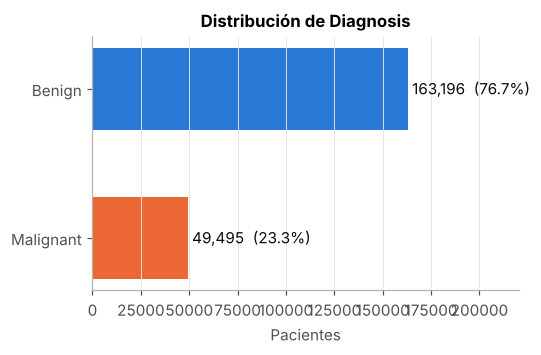

In [4]:
vc = raw[C.TARGET].value_counts()
pct = raw[C.TARGET].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({"n": vc, "%": pct}))

fig, ax = plt.subplots(figsize=(5, 3))
ax.barh(vc.index[::-1], vc.values[::-1], color=[PAL[k] for k in vc.index[::-1]], height=0.55)
for i, (k, v) in enumerate(zip(vc.index[::-1], vc.values[::-1])):
    ax.text(v + 2000, i, f"{v:,}  ({pct[k]}%)", va="center", color="#0b0b0b")
ax.set_xlim(0, vc.max() * 1.35); ax.set_xlabel("Pacientes"); ax.grid(axis="y", visible=False)
ax.set_title("Distribución de Diagnosis")
save(fig, "01_target"); plt.show()

📊 **Datos:** 76.7 % benignos y 23.3 % malignos (ratio ≈ 3.3 : 1).

💭 **Interpretación:** el desbalance es moderado. La *accuracy* sería engañosa (predecir siempre "Benign" daría 76.7 %),
por eso usaremos **recall, precisión, F1 de la clase Malignant, ROC-AUC y PR-AUC**, separación **estratificada** y `class_weight="balanced"`.

### 3.2 Distribuciones de las variables numéricas por diagnóstico

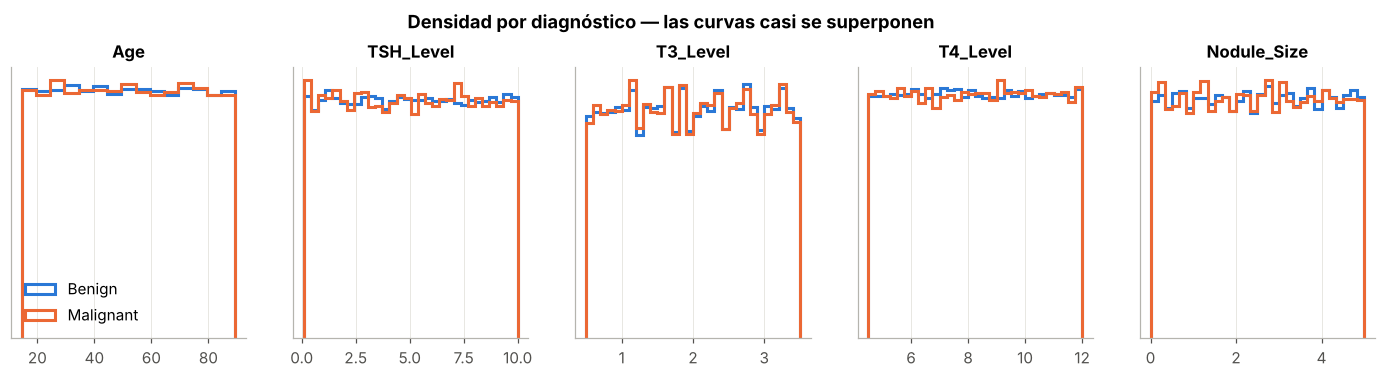

Diagnosis,Benign,Malignant,diferencia,p-valor (Mann-Whitney)
Age,51.917,51.923,0.006,0.9579
TSH_Level,5.049,5.031,-0.018,0.2185
T3_Level,2.003,1.998,-0.005,0.2700
T4_Level,8.245,8.251,0.006,0.5749
Nodule_Size,2.506,2.496,-0.010,0.2201


In [5]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, col in zip(axes, C.NUMERIC_COLS):
    for lab in ["Benign", "Malignant"]:
        bins = np.arange(14.5, 90.5, 5) if col == "Age" else 30   # edad entera: bins de 5 años
        ax.hist(raw.loc[raw[C.TARGET] == lab, col], bins=bins, density=True,
                histtype="step", linewidth=2, color=PAL[lab], label=lab)
    ax.set_title(col); ax.set_yticks([])
axes[0].legend(frameon=False, loc="lower left")
fig.suptitle("Densidad por diagnóstico — las curvas casi se superponen", y=1.04, fontweight="bold")
save(fig, "02_numericas_por_diagnostico"); plt.show()

num_summary = raw.groupby(C.TARGET)[C.NUMERIC_COLS].mean().T.round(3)
num_summary["diferencia"] = (num_summary["Malignant"] - num_summary["Benign"]).round(3)
num_summary["p-valor (Mann-Whitney)"] = [
    stats.mannwhitneyu(raw.loc[raw[C.TARGET]=="Malignant", c], raw.loc[raw[C.TARGET]=="Benign", c]).pvalue
    for c in C.NUMERIC_COLS]
num_summary.round(4)

📊 **Datos:** las 5 variables numéricas tienen distribuciones **aproximadamente uniformes** (planas) y prácticamente idénticas
en benignos y malignos; las diferencias de medias son del orden de centésimas y no son estadísticamente significativas.

💭 **Interpretación:** en este dataset, **ni el perfil hormonal ni el tamaño del nódulo discriminan el diagnóstico**. Esto contradice
la evidencia clínica (el tamaño y las características del nódulo sí importan en la práctica) y es una primera señal de que los datos son
**sintéticos** (generados con distribuciones uniformes independientes). No significa que estas variables no importen en la realidad.

### 3.3 Relación entre factores binarios y malignidad

,variable,tasa_malig_si/grupo1,tasa_malig_no/grupo2,riesgo_relativo,Cramer_V,p_valor
1,Family_History,0.3237,0.1937,1.6707,0.1409,0.0000
3,Iodine_Deficiency,0.3053,0.2086,1.4637,0.0990,0.0000
2,Radiation_Exposure,0.3223,0.2169,1.4861,0.0890,0.0000
6,Diabetes,0.2300,0.2334,0.9854,0.0032,0.1395
0,Gender,0.2332,0.2320,1.0054,0.0014,0.5102
5,Obesity,0.2319,0.2330,0.9951,0.0012,0.5733
4,Smoking,0.2334,0.2325,1.0039,0.0008,0.6958


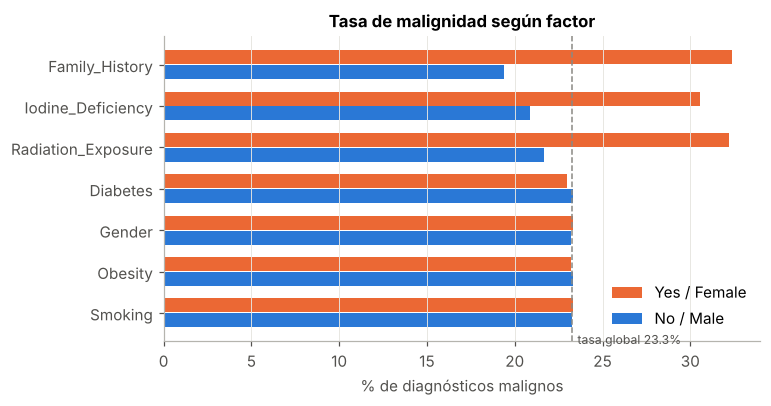

In [6]:
base_rate = (raw[C.TARGET] == "Malignant").mean()
rows = []
for col in C.BINARY_COLS:
    ct = pd.crosstab(raw[col], raw[C.TARGET])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    rate = raw.groupby(col)[C.TARGET].apply(lambda s: (s == "Malignant").mean())
    hi = "Yes" if "Yes" in rate.index else rate.idxmax()
    lo = "No" if "No" in rate.index else rate.idxmin()
    rows.append({"variable": col, "tasa_malig_si/grupo1": rate[hi], "tasa_malig_no/grupo2": rate[lo],
                 "riesgo_relativo": rate[hi] / rate[lo], "Cramer_V": v, "p_valor": p})
bin_tab = pd.DataFrame(rows).sort_values("Cramer_V", ascending=False).round(4)
display(bin_tab)

fig, ax = plt.subplots(figsize=(7, 3.6))
order = bin_tab["variable"][::-1]
y = np.arange(len(order))
ax.barh(y + 0.18, bin_tab.set_index("variable").loc[order, "tasa_malig_si/grupo1"] * 100, height=0.34, color=MALIG, label="Yes / Female")
ax.barh(y - 0.18, bin_tab.set_index("variable").loc[order, "tasa_malig_no/grupo2"] * 100, height=0.34, color=BENIGN, label="No / Male")
ax.axvline(base_rate * 100, color=GRAY, ls="--", lw=1); ax.text(base_rate * 100 + 0.3, -0.75, f"tasa global {base_rate:.1%}", color="#52514e", fontsize=8)
ax.set_yticks(y, order); ax.set_xlabel("% de diagnósticos malignos"); ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right"); ax.set_title("Tasa de malignidad según factor")
save(fig, "03_tasa_malignidad_binarias"); plt.show()

📊 **Datos:** solo tres factores elevan la tasa de malignidad: **Family_History** (32.4 % vs 19.4 %), **Radiation_Exposure** (32.2 % vs 21.7 %)
e **Iodine_Deficiency** (30.5 % vs 20.9 %). Smoking, Obesity, Diabetes y Gender tienen tasas iguales a la global (≈ 23.3 %).

💭 **Interpretación:** los tres factores con efecto son factores de riesgo reconocidos en la literatura (antecedente familiar, radiación ionizante,
déficit de yodo). Que tabaquismo, obesidad y diabetes no tengan **ningún** efecto (tasas idénticas hasta el decimal) refuerza la hipótesis de que el
generador de datos solo asignó efecto a algunas variables. Aun con efecto, los tamaños (Cramér's V ≈ 0.1) son **pequeños**.

### 3.4 Diferencias entre grupos: país y etnia

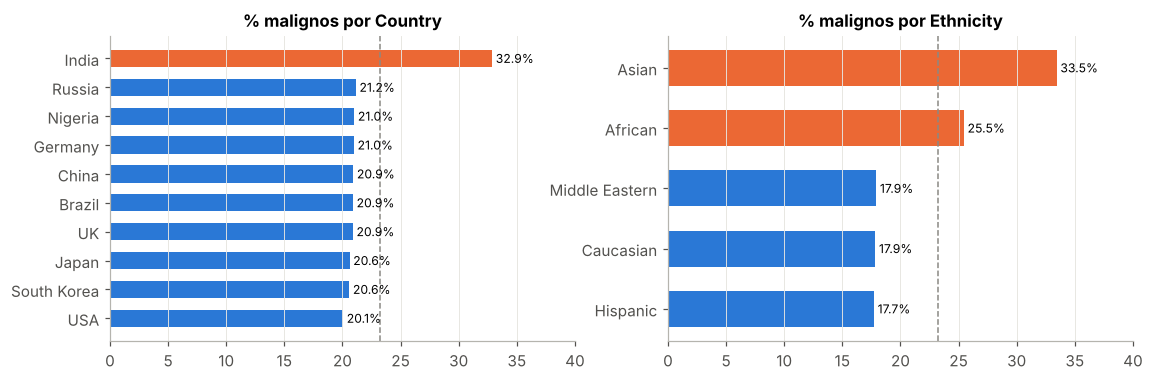

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, col in zip(axes, ["Country", "Ethnicity"]):
    r = raw.groupby(col)[C.TARGET].apply(lambda s: (s == "Malignant").mean() * 100).sort_values()
    colors = [MALIG if v > base_rate * 100 + 2 else BENIGN for v in r.values]
    ax.barh(r.index, r.values, color=colors, height=0.6)
    for i, v in enumerate(r.values): ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)
    ax.axvline(base_rate * 100, color=GRAY, ls="--", lw=1)
    ax.set_title(f"% malignos por {col}"); ax.grid(axis="y", visible=False); ax.set_xlim(0, 40)
save(fig, "04_tasa_por_pais_etnia"); plt.show()

📊 **Datos:** **India** (≈ 33 %) y la etnia **Asian** (≈ 33.5 %) muestran mayor proporción de malignos; **African** está levemente por encima (≈ 25.5 %)
y el resto de grupos en torno a 18–21 %.

💭 **Interpretación:** es una diferencia notable, pero debe leerse con cautela: puede reflejar cómo se construyó el dataset más que un efecto
geográfico real. Además, país y etnia **no están relacionados entre sí** (ver §3.7), lo cual no es realista.

### 3.5 Relaciones entre variables numéricas

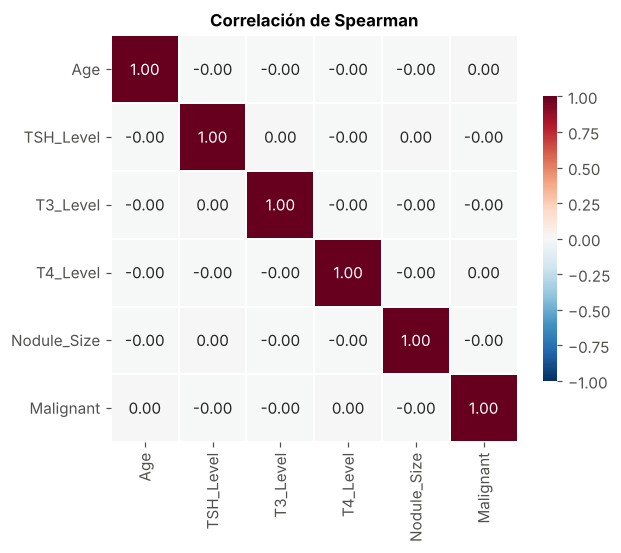

In [8]:
corr_df = raw[C.NUMERIC_COLS].copy()
corr_df["Malignant"] = (raw[C.TARGET] == "Malignant").astype(int)
corr = corr_df.corr(method="spearman")
fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, cbar_kws={"shrink": .7}, ax=ax, linewidths=1, linecolor="white")
ax.set_title("Correlación de Spearman"); ax.grid(False)
save(fig, "05_correlacion"); plt.show()

📊 **Datos:** todas las correlaciones son ≈ 0.00, incluidas TSH–T4 y T3–T4.

💭 **Interpretación:** fisiológicamente, TSH y T4 están relacionadas (eje hipotálamo-hipófisis-tiroides: cuando la T4 sube, la TSH suele bajar).
Su independencia total confirma que **las hormonas se generaron al azar de manera independiente**. No hay multicolinealidad que tratar.

### 3.6 `Thyroid_Cancer_Risk` frente a `Diagnosis`

Diagnosis,Benign,Malignant
Thyroid_Cancer_Risk,,
Low,85.0,15.0
Medium,84.9,15.1
High,30.0,70.0


,Family_History,Radiation_Exposure,Iodine_Deficiency,India,Asian
Thyroid_Cancer_Risk,,,,,
Low,24.1,12.2,21.0,15.8,19.6
Medium,24.1,12.1,21.0,15.8,19.6
High,63.4,30.9,47.2,43.8,55.9


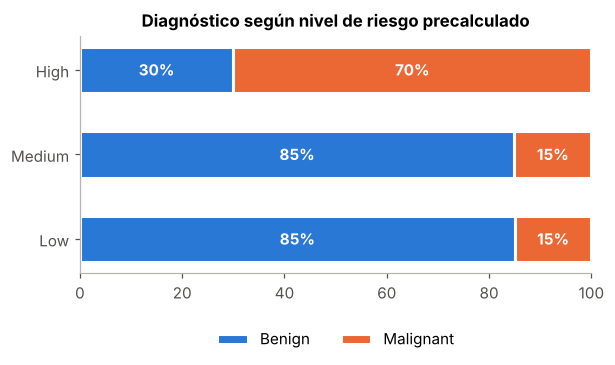

In [9]:
ct = pd.crosstab(raw["Thyroid_Cancer_Risk"], raw[C.TARGET], normalize="index").loc[["Low", "Medium", "High"]]
display((ct * 100).round(1))
prof = raw.assign(**{c: raw[c].eq("Yes") for c in ["Family_History", "Radiation_Exposure", "Iodine_Deficiency"]},
                  India=raw["Country"].eq("India"), Asian=raw["Ethnicity"].eq("Asian"))
display(prof.groupby("Thyroid_Cancer_Risk")[["Family_History", "Radiation_Exposure", "Iodine_Deficiency", "India", "Asian"]]
        .mean().loc[["Low", "Medium", "High"]].mul(100).round(1))

fig, ax = plt.subplots(figsize=(6, 2.8))
left = np.zeros(3)
for lab in ["Benign", "Malignant"]:
    ax.barh(ct.index, ct[lab] * 100, left=left, color=PAL[lab], label=lab, height=0.55, edgecolor="white", linewidth=2)
    for i, v in enumerate(ct[lab] * 100): ax.text(left[i] + v / 2, i, f"{v:.0f}%", ha="center", va="center", color="white", fontweight="bold")
    left += ct[lab].values * 100
ax.set_xlim(0, 100); ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(.5, -.18)); ax.grid(False)
ax.set_title("Diagnóstico según nivel de riesgo precalculado")
save(fig, "06_riesgo_vs_diagnostico"); plt.show()

📊 **Datos:** "High" tiene 70 % de malignos; **"Low" y "Medium" tienen exactamente la misma tasa (≈ 15 %)** y el mismo perfil de factores.
Los pacientes "High" concentran los factores con efecto (antecedente familiar, India, Asian…).

💭 **Interpretación:** `Thyroid_Cancer_Risk` parece un **puntaje derivado de los mismos factores** y muy cercano al resultado. No sabemos cómo ni cuándo
se calculó (¿antes o después del diagnóstico?). Usarlo como predictor podría introducir **fuga de información** y, en todo caso, sería redundante.
**Decisión:** excluirlo del modelo y usar la regla *"High ⇒ Malignant"* como **baseline del dominio**. Además, la categoría "Medium" no aporta
información distinta a "Low": es una inconsistencia del dataset.

### 3.7 Patrones y anomalías

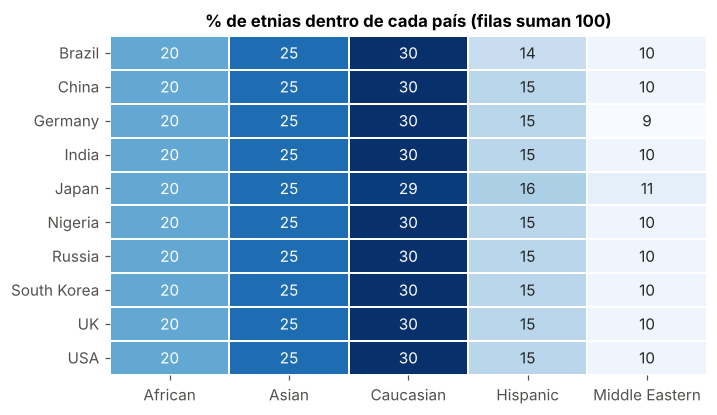

,Female,Male,No,Yes
Gender,0.6,0.4,NaN,NaN
Family_History,NaN,NaN,0.700,0.300
Radiation_Exposure,NaN,NaN,0.850,0.150
Smoking,NaN,NaN,0.801,0.199
Obesity,NaN,NaN,0.700,0.300
Diabetes,NaN,NaN,0.800,0.200


In [10]:
ce = pd.crosstab(raw["Country"], raw["Ethnicity"], normalize="index").mul(100).round(0)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ce, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=ax, linewidths=1, linecolor="white")
ax.set_title("% de etnias dentro de cada país (filas suman 100)"); ax.grid(False); ax.set_ylabel(""); ax.set_xlabel("")
save(fig, "07_pais_vs_etnia"); plt.show()

prop = {c: raw[c].value_counts(normalize=True).round(3).to_dict() for c in ["Gender", "Family_History", "Radiation_Exposure", "Smoking", "Obesity", "Diabetes"]}
pd.DataFrame(prop).T

📊 **Datos:** la composición étnica es **la misma en todos los países** (≈ 30 % Caucasian, 25 % Asian, 20 % African…), incluso en Nigeria o Japón.
Las proporciones de las binarias son números redondos (60/40, 70/30, 85/15, 80/20).

💭 **Interpretación:** son patrones imposibles en una población real. Concluimos que el dataset es **sintético**. Las conclusiones del proyecto serán
válidas **sobre este dataset** y **no deben extrapolarse** a pacientes reales. Esto se documenta como limitación principal.

### 3.8 Problemas de calidad que condicionan decisiones
Ver §4: no hay faltantes ni duplicados; el principal problema no es de *limpieza* sino de *validez* (señal débil, variables generadas de forma independiente, variable de riesgo redundante).

## 4. Calidad y preparación de datos

In [11]:
qr = quality_report(raw)
qr

,columna,tipo,faltantes,unicos,fuera_de_rango
0,Patient_ID,int64,0,212691,NaN
1,Age,int64,0,75,0.0
2,Gender,str,0,2,NaN
3,Country,str,0,10,NaN
4,Ethnicity,str,0,5,NaN
5,Family_History,str,0,2,NaN
6,Radiation_Exposure,str,0,2,NaN
7,Iodine_Deficiency,str,0,2,NaN
8,Smoking,str,0,2,NaN
9,Obesity,str,0,2,NaN


In [12]:
print("Duplicados exactos (sin ID):", raw.drop(columns=C.ID_COL).duplicated().sum())
print("IDs repetidos:", raw[C.ID_COL].duplicated().sum())
print("\nValores únicos en categóricas:")
for c in C.CATEGORICAL_COLS + ["Thyroid_Cancer_Risk", C.TARGET]:
    vals = raw[c].unique().tolist()
    print(f"  {c:20s} {vals}")
# Variantes de escritura (mayúsculas/espacios)
inconsist = {c: raw[c].nunique() - raw[c].str.strip().str.lower().nunique() for c in C.CATEGORICAL_COLS}
print("\nCategorías que colapsan al normalizar texto:", inconsist)

Duplicados exactos (sin ID): 0
IDs repetidos: 0

Valores únicos en categóricas:
  Gender               ['Male', 'Female']
  Family_History       ['No', 'Yes']
  Radiation_Exposure   ['Yes', 'No']
  Iodine_Deficiency    ['No', 'Yes']
  Smoking              ['No', 'Yes']
  Obesity              ['No', 'Yes']
  Diabetes             ['No', 'Yes']
  Country              ['Russia', 'Germany', 'Nigeria', 'India', 'UK', 'South Korea', 'Brazil', 'China', 'Japan', 'USA']
  Ethnicity            ['Caucasian', 'Hispanic', 'Asian', 'African', 'Middle Eastern']
  Thyroid_Cancer_Risk  ['Low', 'Medium', 'High']
  Diagnosis            ['Benign', 'Malignant']



Categorías que colapsan al normalizar texto: {'Gender': 0, 'Family_History': 0, 'Radiation_Exposure': 0, 'Iodine_Deficiency': 0, 'Smoking': 0, 'Obesity': 0, 'Diabetes': 0, 'Country': 0, 'Ethnicity': 0}


In [13]:
# Outliers por regla IQR y verificación de rangos lógicos
out = []
for c in C.NUMERIC_COLS:
    q1, q3 = raw[c].quantile([.25, .75]); iqr = q3 - q1
    n_iqr = ((raw[c] < q1 - 1.5 * iqr) | (raw[c] > q3 + 1.5 * iqr)).sum()
    lo, hi = C.VALID_RANGES[c]
    out.append({"variable": c, "min": raw[c].min(), "max": raw[c].max(), "outliers_IQR": n_iqr,
                "rango_valido": f"[{lo}, {hi}]", "fuera_de_rango": (~raw[c].between(lo, hi)).sum()})
display(pd.DataFrame(out))

# Reglas lógicas / clínicas
rules = {
    "Nodule_Size = 0 (sin nódulo)": (raw["Nodule_Size"] == 0).sum(),
    "Age < 18": (raw["Age"] < 18).sum(),
    "TSH alta (>4.5) y T4 alta (>11) a la vez": ((raw["TSH_Level"] > 4.5) & (raw["T4_Level"] > 11)).sum(),
    "TSH fuera de referencia (0.4–4.5)": (~raw["TSH_Level"].between(0.4, 4.5)).sum(),
}
pd.Series(rules, name="n_registros").to_frame().assign(pct=lambda d: (d.n_registros / len(raw) * 100).round(2))

,variable,min,max,outliers_IQR,rango_valido,fuera_de_rango
0,Age,15.0,89.0,0,"[0, 120]",0
1,TSH_Level,0.1,10.0,0,"[0, 100]",0
2,T3_Level,0.5,3.5,0,"[0, 10]",0
3,T4_Level,4.5,12.0,0,"[0, 30]",0
4,Nodule_Size,0.0,5.0,0,"[0, 10]",0


,n_registros,pct
Nodule_Size = 0 (sin nódulo),196,0.09
Age < 18,8571,4.03
TSH alta (>4.5) y T4 alta (>11) a la vez,15609,7.34
TSH fuera de referencia (0.4–4.5),124472,58.52


📊 **Datos:**
- **Faltantes:** 0 en todas las columnas. **Duplicados:** 0 (ni filas ni IDs). **Tipos:** correctos (5 numéricas, 9 categóricas en texto, objetivo binario).
- **Categorías inconsistentes:** ninguna (sin variantes de mayúsculas/espacios).
- **Outliers (IQR):** 0. Todos los valores caen dentro de rangos válidos; las distribuciones son uniformes con límites "duros".
- **Reglas clínicas:** ≈ 58.5 % de los pacientes tiene TSH fuera del rango de referencia y hay combinaciones fisiológicamente raras (TSH alta con T4 alta).
  Hay 196 pacientes con `Nodule_Size = 0` (sin nódulo medible) y 8 571 (4 %) menores de 18 años; 7.3 % combina TSH alta con T4 alta.

💭 **Decisiones y justificación:**
1. **No se imputa ni se eliminan outliers:** no hay faltantes y los extremos son valores plausibles dentro del rango; eliminarlos solo reduciría datos.
   Aun así, el Pipeline incluye `SimpleImputer` para que el flujo sea robusto si en producción llegan valores vacíos.
2. **No se corrigen las combinaciones hormonales raras:** no tenemos criterio clínico ni información de unidades para decidir que son errores. Se documentan como riesgo.
3. **Se excluyen** `Patient_ID` (identificador, sin información) y `Thyroid_Cancer_Risk` (posible fuga / redundancia, §3.6).
4. **Transformaciones:** estandarización de numéricas (solo para Regresión Logística, sensible a la escala) y One-Hot de categóricas (`drop="if_binary"` para binarias).
   Los árboles no necesitan escalado.
5. La limpieza determinista (`clean()`) no aprende parámetros, por lo que puede aplicarse antes del split sin fuga.

In [14]:
df = clean(raw)
print("Filas tras limpieza:", len(df), "(eliminadas:", len(raw) - len(df), ")")

Filas tras limpieza: 212691 (eliminadas: 0 )


## 5. Separación de los datos

In [15]:
X, y = get_xy(df)
X_train, X_val, X_test, y_train, y_val, y_test = split(X, y)
split_tab = pd.DataFrame({
    "n": [len(X_train), len(X_val), len(X_test)],
    "% del total": [len(X_train) / len(X) * 100, len(X_val) / len(X) * 100, len(X_test) / len(X) * 100],
    "% Malignant": [y_train.mean() * 100, y_val.mean() * 100, y_test.mean() * 100],
}, index=["train", "validation", "test"]).round(2)
split_tab

,n,% del total,% Malignant
train,148883,70.0,23.27
validation,31904,15.0,23.27
test,31904,15.0,23.27


- **Estrategia:** hold-out estratificado **70 / 15 / 15** (train / validation / test) con `random_state=42`. Complementamos con **validación cruzada estratificada de 5 folds sobre train** para medir estabilidad.
- **Razón:** con ≈ 213 mil registros, 15 % (≈ 32 mil) da estimaciones estables; la estratificación mantiene el 23.3 % de malignos en cada parte. No hay dimensión temporal ni pacientes repetidos, así que un split aleatorio es válido.
- **Contra el data leakage:** (1) el split se hace **antes** de cualquier transformación con parámetros; (2) escalado, imputación y codificación viven dentro del `Pipeline` y se ajustan solo con train (también dentro de cada fold de CV); (3) se excluye `Thyroid_Cancer_Risk`; (4) **el conjunto de test no se usa en el TP1**: se reserva para la evaluación final del TF1; la selección de modelos se hace con validation.

## 6. Flujo reproducible de preprocesamiento

In [16]:
prep = build_preprocessor()
prep.fit(X_train)                       # se ajusta SOLO con train
print("Variables numéricas →", C.NUMERIC_COLS, "→ SimpleImputer(median) + StandardScaler")
print("Variables categóricas →", C.CATEGORICAL_COLS, "→ SimpleImputer(most_frequent) + OneHotEncoder")
print("\nN.º de variables tras transformación:", len(prep.get_feature_names_out()))
print(list(prep.get_feature_names_out()))
prep

Variables numéricas → ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size'] → SimpleImputer(median) + StandardScaler
Variables categóricas → ['Gender', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'Country', 'Ethnicity'] → SimpleImputer(most_frequent) + OneHotEncoder

N.º de variables tras transformación: 27
['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size', 'Gender_Male', 'Family_History_Yes', 'Radiation_Exposure_Yes', 'Iodine_Deficiency_Yes', 'Smoking_Yes', 'Obesity_Yes', 'Diabetes_Yes', 'Country_Brazil', 'Country_China', 'Country_Germany', 'Country_India', 'Country_Japan', 'Country_Nigeria', 'Country_Russia', 'Country_South Korea', 'Country_UK', 'Country_USA', 'Ethnicity_African', 'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Hispanic', 'Ethnicity_Middle Eastern']


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The

## 7. Baseline

In [17]:
from sklearn.dummy import DummyClassifier
results, scores, preds = {}, {}, {}

pipes = make_pipelines()
for name in ["Baseline (Dummy estratificado)"]:
    p = pipes[name].fit(X_train, y_train)
    scores[name] = p.predict_proba(X_val)[:, 1]; preds[name] = p.predict(X_val)
    results[name] = evaluate(y_val, preds[name], scores[name])

dummy_mf = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
results["Baseline (siempre Benign)"] = evaluate(y_val, dummy_mf.predict(X_val), dummy_mf.predict_proba(X_val)[:, 1])

# Regla del dominio: High ⇒ Malignant (usa el puntaje precalculado SOLO como referencia)
risk_val = df.loc[X_val.index, "Thyroid_Cancer_Risk"]
rule_pred = (risk_val == "High").astype(int).values
rule_score = risk_val.map({"Low": 0, "Medium": 1, "High": 2}).values
results["Regla dominio (Risk = High)"] = evaluate(y_val, rule_pred, rule_score)
preds["Regla dominio (Risk = High)"] = rule_pred
results_table(results)

,Recall (Malignant),Precision (Malignant),F1 (Malignant),Balanced Accuracy,Specificity,ROC-AUC,PR-AUC
Baseline (Dummy estratificado),0.226,0.227,0.227,0.496,0.767,0.496,0.231
Baseline (siempre Benign),0.000,0.000,0.000,0.500,1.000,0.500,0.233
Regla dominio (Risk = High),0.453,0.701,0.550,0.697,0.941,0.701,0.465


📊 **Datos:** el Dummy estratificado tiene ROC-AUC ≈ 0.50 (azar) y "siempre Benign" tiene recall 0. La **regla del dominio** alcanza recall ≈ 0.45 con precisión ≈ 0.70 y ROC-AUC ≈ 0.70.

💭 **Interpretación:** el Dummy es el piso mínimo; la regla "Risk = High" es un **baseline exigente**: cualquier modelo útil debería al menos igualarla sin usar ese puntaje.

## 8. Modelos preliminares

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import time
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=C.RANDOM_STATE)
cv_rows = {}
for name in ["Regresión Logística", "Random Forest", "HistGradientBoosting"]:
    t = time.time()
    cv_auc = cross_val_score(pipes[name], X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
    p = pipes[name].fit(X_train, y_train)
    scores[name] = p.predict_proba(X_val)[:, 1]; preds[name] = p.predict(X_val)
    results[name] = evaluate(y_val, preds[name], scores[name])
    cv_rows[name] = {"CV ROC-AUC media": cv_auc.mean(), "CV ROC-AUC desv.": cv_auc.std(), "segundos": time.time() - t}
pd.DataFrame(cv_rows).T.round(4)

,CV ROC-AUC media,CV ROC-AUC desv.,segundos
Regresión Logística,0.6703,0.0029,4.7597
Random Forest,0.6961,0.0032,72.4484
HistGradientBoosting,0.6949,0.0019,14.8148


**Justificación de los modelos:**
- **Regresión Logística** (`class_weight="balanced"`): modelo lineal, interpretable (coeficientes ≈ log-odds), adecuado cuando el efecto de factores binarios es aditivo.
- **Random Forest** y **HistGradientBoosting**: capturan interacciones y no linealidades (por ejemplo, combinación de antecedente + país) sin escalar variables; HGB es eficiente con 150 mil filas.

📊 **Datos:** la desviación de ROC-AUC entre folds es muy baja (≈ 0.003), por lo que las diferencias entre modelos no se deben a una partición afortunada.

## 9. Evaluación preliminar (conjunto de validación)

In [19]:
tab = results_table(results)
tab.to_csv(C.REPORTS_DIR / "metricas_validacion.csv")
tab

,Recall (Malignant),Precision (Malignant),F1 (Malignant),Balanced Accuracy,Specificity,ROC-AUC,PR-AUC
Baseline (Dummy estratificado),0.226,0.227,0.227,0.496,0.767,0.496,0.231
Baseline (siempre Benign),0.000,0.000,0.000,0.500,1.000,0.500,0.233
Regla dominio (Risk = High),0.453,0.701,0.550,0.697,0.941,0.701,0.465
Regresión Logística,0.615,0.352,0.448,0.636,0.657,0.670,0.435
Random Forest,0.453,0.700,0.550,0.697,0.941,0.697,0.499
HistGradientBoosting,0.453,0.700,0.550,0.697,0.941,0.700,0.500


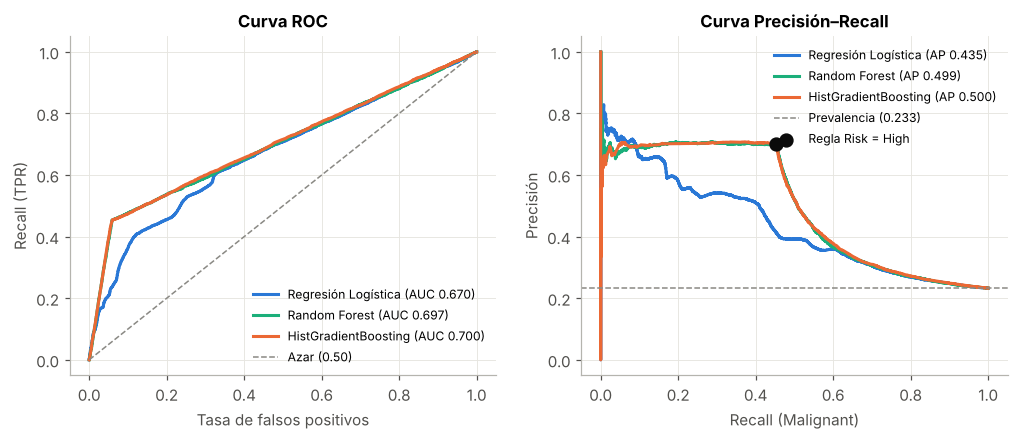

In [20]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
model_names = ["Regresión Logística", "Random Forest", "HistGradientBoosting"]
cols = {"Regresión Logística": "#2a78d6", "Random Forest": "#1baf7a", "HistGradientBoosting": "#eb6834"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for n in model_names:
    fpr, tpr, _ = roc_curve(y_val, scores[n]); axes[0].plot(fpr, tpr, lw=2, color=cols[n], label=f"{n} (AUC {results[n]['ROC-AUC']:.3f})")
    pr, rc, _ = precision_recall_curve(y_val, scores[n]); axes[1].plot(rc, pr, lw=2, color=cols[n], label=f"{n} (AP {results[n]['PR-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], ls="--", color=GRAY, lw=1, label="Azar (0.50)")
axes[1].axhline(y_val.mean(), ls="--", color=GRAY, lw=1, label=f"Prevalencia ({y_val.mean():.3f})")
rp = results["Regla dominio (Risk = High)"]
axes[1].scatter([rp["Recall (Malignant)"]], [rp["Precision (Malignant)"]], s=70, color="#0b0b0b", zorder=5, label="Regla Risk = High")
axes[0].set(xlabel="Tasa de falsos positivos", ylabel="Recall (TPR)", title="Curva ROC")
axes[1].set(xlabel="Recall (Malignant)", ylabel="Precisión", title="Curva Precisión–Recall")
axes[0].legend(frameon=False, fontsize=8, loc="lower right"); axes[1].legend(frameon=False, fontsize=8, loc="upper right")
save(fig, "08_roc_pr"); plt.show()

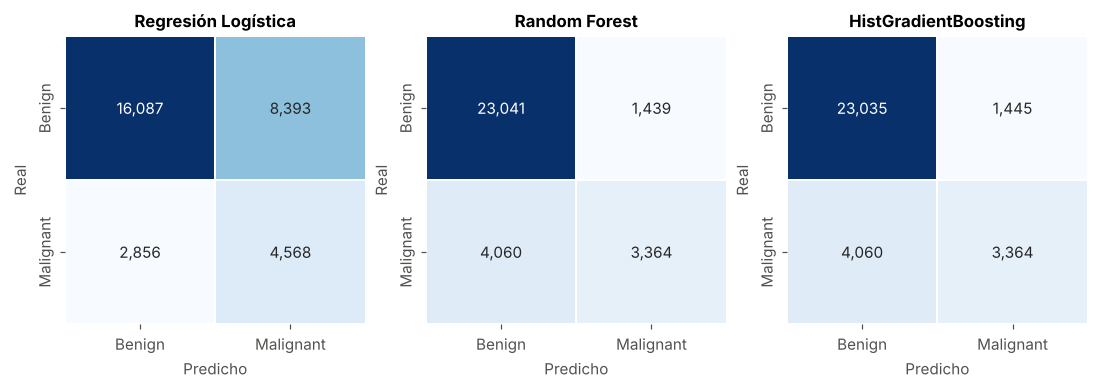

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, n in zip(axes, model_names):
    cm = confusion_matrix(y_val, preds[n])
    sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"], linewidths=1, linecolor="white")
    ax.set(title=n, xlabel="Predicho", ylabel="Real"); ax.grid(False)
save(fig, "09_matrices_confusion"); plt.show()

In [22]:
# ¿Qué precisión tendríamos si exigimos recall alto? (análisis de umbral sobre validación)
best = "HistGradientBoosting"
pr, rc, th = precision_recall_curve(y_val, scores[best])
rows = []
for target in [0.45, 0.60, 0.80, 0.90, 0.95]:
    i = np.where(rc[:-1] >= target)[0][-1]
    rows.append({"recall objetivo": target, "umbral": th[i], "precisión": pr[i],
                 "% pacientes marcados como positivos": (scores[best] >= th[i]).mean() * 100})
pd.DataFrame(rows).round(3)

,recall objetivo,umbral,precisión,% pacientes marcados como positivos
0,0.45,0.836,0.701,14.945
1,0.60,0.378,0.377,37.011
2,0.80,0.368,0.272,68.393
3,0.90,0.361,0.249,84.218
4,0.95,0.351,0.240,92.151


Coincidencia de predicciones HGB vs regla Risk=High: 100.0%


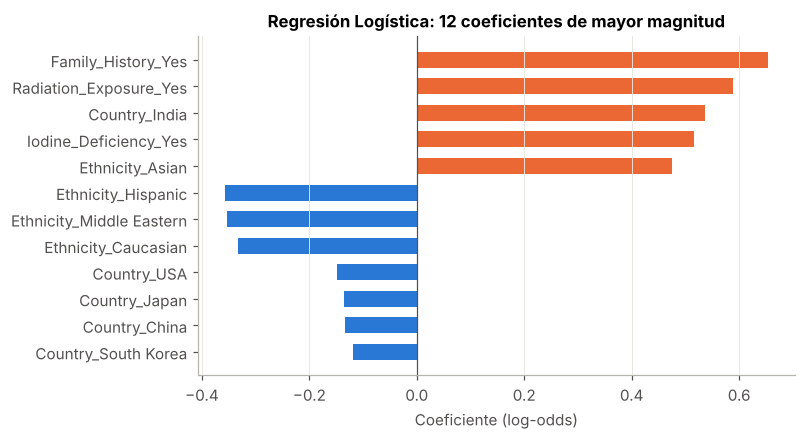

In [23]:
# ¿Los modelos de árboles encontraron algo distinto a la regla Risk = High?
agree = (preds["HistGradientBoosting"] == rule_pred).mean()
print(f"Coincidencia de predicciones HGB vs regla Risk=High: {agree:.1%}")

# Lectura preliminar de factores (coeficientes de la Regresión Logística)
lr = pipes["Regresión Logística"]
coef = pd.Series(lr.named_steps["model"].coef_[0], index=lr.named_steps["prep"].get_feature_names_out())
top = coef.reindex(coef.abs().sort_values(ascending=False).index).head(12)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top.index[::-1], top.values[::-1], color=[MALIG if v > 0 else BENIGN for v in top.values[::-1]], height=0.6)
ax.axvline(0, color="#52514e", lw=0.8); ax.grid(axis="y", visible=False)
ax.set(title="Regresión Logística: 12 coeficientes de mayor magnitud", xlabel="Coeficiente (log-odds)")
save(fig, "10_coeficientes_lr"); plt.show()

### Interpretación de la evaluación

📊 **Datos (validación):**
- **HistGradientBoosting** y **Random Forest** obtienen ROC-AUC ≈ 0.70 y PR-AUC ≈ 0.50, frente a 0.50 / 0.23 del Dummy. Con umbral 0.5 detectan ≈ 45 % de los malignos con precisión ≈ 70 % y especificidad ≈ 94 %.
- La **Regresión Logística** tiene más recall (≈ 0.61) pero mucha menor precisión (≈ 0.35) y AUC algo menor (≈ 0.67): al ser aditiva no captura bien las combinaciones de factores.
- Los modelos de árboles **coinciden al 100 % con la regla `Risk = High`** con umbral 0.5: no la superan, la reproducen. Solo mejoran levemente el ordenamiento (PR-AUC 0.500 vs 0.465).
- Para alcanzar **recall de 90 %** la precisión cae a ≈ 0.25 (apenas sobre la prevalencia de 0.23) y habría que marcar como positivos al 84 % de los pacientes.

💭 **Interpretación:**
- **Por qué estas métricas:** en triaje oncológico un falso negativo (maligno no detectado) es más costoso que un falso positivo, por eso priorizamos **recall de Malignant**; pero la precisión importa porque cada falso positivo implica estudios innecesarios. **PR-AUC** es más informativa que la accuracy con clases desbalanceadas, y **ROC-AUC** mide la capacidad de ordenar pacientes independientemente del umbral.
- Los modelos sí aprenden señal real (muy por encima del azar), pero esa señal se limita a los factores de §3.3–3.4 (antecedente, radiación, yodo, India/Asian). **El techo de desempeño lo pone el dataset**, no el algoritmo: las variables hormonales y el nódulo no aportan.
- El criterio inicial de "recall > 90 %" **no es alcanzable con una precisión útil** en estos datos; lo replanteamos como "maximizar recall con precisión ≥ umbral aceptable", definiendo el umbral en el TF1.
- Los coeficientes de la Regresión Logística apuntan a los mismos factores del EDA, lo cual es coherente.
- **Hipótesis (a verificar en el TF1):** el patrón sugiere que el generador asignó primero `Thyroid_Cancer_Risk` a partir de los factores y luego `Diagnosis` a partir del riesgo (≈ 70 % malignos si High, ≈ 15 % si no). Si es así, ningún modelo podrá superar sustancialmente este techo.

## 10. Estado del proyecto y plan hacia el TF1

**Principales hallazgos**
1. Diagnóstico desbalanceado (23.3 % malignos).
2. Solo antecedente familiar, radiación, deficiencia de yodo, India y etnia asiática se asocian con malignidad; hormonas, nódulo, edad, sexo, tabaquismo, obesidad y diabetes no.
3. El dataset muestra señales claras de ser **sintético** (distribuciones uniformes, correlaciones nulas entre hormonas, etnia independiente del país).
4. `Thyroid_Cancer_Risk` es un puntaje redundante y potencialmente con fuga; se excluyó y se usó como baseline del dominio.
5. Mejor modelo preliminar: HistGradientBoosting (ROC-AUC 0.70, PR-AUC 0.50 en validación), equivalente a la regla del dominio.

**Problemas no resueltos**
- Elegir el **umbral de decisión** según un costo explícito FN vs FP.
- Confirmar si existe señal en **interacciones** que los modelos no aprovechan aún.

**Limitaciones**
- Validez externa nula: los resultados no se pueden extrapolar a pacientes reales.
- No sabemos cómo se generó `Diagnosis` ni `Thyroid_Cancer_Risk`.
- Faltan variables clínicas clave (ecografía TI-RADS, citología, edad del nódulo, etc.).

**Mejoras y actividades hacia el TF1**
| # | Actividad | Herramienta |
|---|---|---|
| 1 | Ajuste de hiperparámetros con validación cruzada | Optuna |
| 2 | Registro de experimentos (configuración → métrica) | MLflow |
| 3 | Selección de umbral por costo (FN pesa más que FP) y calibración de probabilidades | scikit-learn |
| 4 | Interpretabilidad global y local | SHAP |
| 5 | Análisis de errores: falsos negativos (malignos con perfil de riesgo bajo) | pandas / SHAP |
| 6 | Técnica adicional justificada: clustering de perfiles de riesgo para entender segmentos | K-Means / UMAP |
| 7 | Evaluación final única sobre test | — |
| 8 | Demo de uso (formulario → probabilidad) | Streamlit |

**Declaración de uso de IA generativa:** se utilizó un asistente de IA (Claude) como apoyo para organizar el código, la estructura del repositorio y la redacción.
El grupo revisó, ejecutó y validó todos los resultados y es responsable de su interpretación.